# 导入依赖

In [5]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import joblib
from hyperopt import hp
import re
import pandas as pd
import json
import numpy as np
import json
import hashlib
import datetime
import platform
import numpy as np
import pandas as pd
import torch
import sklearn
import scorecardpy as sc
import math
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV as gscv
import copy
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')
from hyperopt import hp
from hyperopt.pyll.stochastic import sample
import csv
from hyperopt import STATUS_OK
from timeit import default_timer as timer
from sklearn.metrics import roc_auc_score
from collections import Counter
import math
%matplotlib inline
import joblib

In [6]:
def sk_var_est(data,var,flag,cut=None,q=10):
    '''
    skleran逻辑回归评价函数，包括AUC\KS\等频分箱后KS
    ------
    Params
    ------
    model: sklearn逻辑回归模型
    data: 数据集
    model_var:入模变量
    flag:y标签
    cut：拆分数据集
    q：等频分箱箱数
    '''
    data['prob'] = data[var].copy()
    data['prob_q'] = pd.qcut(data['prob'],q=q,duplicates='drop')
    q1 = len(data['prob_q'].unique())
    data['prob_q'] = pd.qcut(data['prob'], q=q, labels=range(q1),duplicates='drop')
    auc_ = [roc_auc_score(y_true=data[flag], y_score=data['prob'])]
    fpr, tpr, _ = roc_curve(y_true=data[flag], y_score=data['prob'])
    ks = [max(abs(tpr - fpr))]
    fpr_q, tpr_q, _ = roc_curve(y_true=data[flag], y_score=data['prob_q'])
    ks_q = [max(abs(fpr_q - tpr_q))]
    data_set = ['all']

    datas = data[['prob','prob_q',flag,cut]].copy()
    if cut is not None:
        for i in data[cut].unique():
            auc_.append(roc_auc_score(y_true=datas[datas[cut]==i][flag], y_score=datas[datas[cut]==i]['prob']))
            fpr, tpr, _ = roc_curve(y_true=datas[datas[cut]==i][flag], y_score=datas[datas[cut]==i]['prob'])
            ks.append(max(abs(tpr - fpr)))
            fpr_q, tpr_q, _ = roc_curve(y_true=datas[datas[cut]==i][flag], y_score=datas[datas[cut]==i]['prob_q'])
            ks_q.append(max(abs(fpr_q - tpr_q)))
            data_set.append(i)
    data_est = pd.DataFrame({"dataset":data_set,"auc":auc_,"ks":ks,"ks_q"+str(q):ks_q})
    data_est['auc'] = data_est['auc']
    return data_est[["dataset","auc","ks","ks_q"+str(q)]]

In [7]:
def feature_importance(model):
    gain = pd.DataFrame({'feature': model.feature_name(
    ), 'gain': model.feature_importance(importance_type='gain')})
    split = pd.DataFrame({'feature': model.feature_name(
    ), 'split': model.feature_importance(importance_type='split')})
    out = gain.merge(split, how='left', on=['feature'], validate='1:1')
    return out

# 读数据

In [8]:
model = joblib.load('/opt/workspace/work/wangluyang/21.大模型探索/优化模型/model_lgb.pkl')
imp = feature_importance(model)
feats100 = imp.sort_values(by = ['gain'], ascending = False).head(100)['feature'].tolist()
print(len(feats100))

feats200 = imp.sort_values(by = ['gain'], ascending = False).head(200)['feature'].tolist()
print(len(feats200))

feats300 = imp.sort_values(by = ['gain'], ascending = False).head(300)['feature'].tolist()
print(len(feats300))

feats400 = imp.sort_values(by = ['gain'], ascending = False).head(400)['feature'].tolist()
print(len(feats400))

feats500 = imp.sort_values(by = ['gain'], ascending = False).head(500)['feature'].tolist()
print(len(feats500))

100
200
300
400
500


In [9]:
df = pd.read_pickle('/opt/workspace/work/wangluyang/21.大模型探索/优化模型/data/rs_data_train.pickle')
print(df.shape)
df.head(2)

(52535, 949)


,cus_num,id,cell,name,user_date,other_var3,other_var5,other_var4,other_var6,other_var7,...,qle_ind_a_m12_50_nz,qle_ind_a_m12v_50_nz,qle_ind_r_company_scale_4,qle_ind_r_m12v_3,qle_ind_r_m3_std,qle_ind_r_m3_95_nz,qle_ind_r_m3_std_nz,rsm_scoreriskass_offline,role,month
9,641665,ccb5525662508904fb6237930d1dd8a9,9183298e2bf9d553d28e8d80dc544fb7,781392ac77c7ea87e1eb2291964d3ce1,2025-10-07,0.0,0.0,圆梦树,榕树-圆梦树-新,榕树,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.157072,train,2025-10
14,96849,73019586293814bc2960f9a000524c23,9b1fa0065eb5caf8139a885ae2ec5602,17209443a11e33d32b3b03b314664f67,2025-11-24,0.0,0.0,圆梦树,榕树-圆梦树-新,榕树,...,4.0,4.0,-0.377186,-0.267362,-0.219354,-0.2,-0.242977,0.128529,train,2025-11


In [10]:
df1w = df.sample(n = 10000, random_state = 42)
df2w = df.sample(n = 20000, random_state = 42)
df3w = df.sample(n = 30000, random_state = 42)
df5w = df.sample(n = 50000, random_state = 42)
df1w.shape,df2w.shape,df3w.shape,df5w.shape

((10000, 949), (20000, 949), (30000, 949), (50000, 949))

In [11]:
feats = feats100
print(len(feats))
col_target = 'other_var3'

X_train = df1w[feats]
y_train = df1w[col_target]

100


In [12]:
clf = joblib.load('/opt/workspace/work/wangluyang/21.大模型探索/优化模型_new/credit_risk_tab2.5_n1_f100_10000/credit_risk_tab2.5_n1_f100_10000.pkl')
feats = feats100
from tqdm import tqdm
batch_size = 3000  
predictions = [] 
predictions_prob = [] 
for i in tqdm(range(0, len(df), batch_size)): 
    batch = df[i:i+batch_size][feats].copy()
    # batch.shape 
    batch_preds_prob = clf.predict_proba(batch[feats])[:, 1]
    predictions_prob.extend(batch_preds_prob)
    import torch
    import gc
    gc.collect()
    torch.cuda.empty_cache()
df['prob'] = predictions_prob
sk_var_est(df,'prob','other_var3','other_var6',q=10)

100%|██████████| 18/18 [02:02<00:00,  6.82s/it]


,dataset,auc,ks,ks_q10
0,all,0.636185,0.197680,0.192316
1,榕树-圆梦树-新,0.636462,0.197326,0.191301
2,榕树-快易花优选贷,0.614685,0.174257,0.165553
3,榕树-恒小花,0.624781,0.186913,0.183590
4,榕树-绿地小贷,0.632067,0.198885,0.180398
5,榕树-适意花,0.645071,0.223679,0.207169
6,榕树-极融你我贷36,0.621309,0.174402,0.169452


# 创建新数据集测试

In [29]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_samples = 1000
feats100 = ['age', 'income', 'city', 'education']

# 生成数据
data = {
    'age': np.random.randint(18, 70, n_samples),
    'income': np.random.normal(50000, 15000, n_samples).astype(float),  # 改为 float
    'city': np.random.choice(['bj', 'sh', 'gz', 'sz', 'hz'], n_samples).tolist(),
    'education': np.random.choice(['high_school', 'bachelor', 'master', 'phd'], n_samples).tolist(),
}
df = pd.DataFrame(data)

# 添加缺失值
for _ in range(50):
    df.loc[np.random.randint(0, n_samples), 'city'] = np.nan
for _ in range(30):
    df.loc[np.random.randint(0, n_samples), 'income'] = np.nan

# 标签
y = np.random.choice([0, 1], n_samples, p=[0.85, 0.15])
df['default_flag'] = y  # 可选

X = df[feats100]
y = df['default_flag']  # 或者 y = ...


# io_schema

In [14]:
import numpy as np
import pandas as pd

def generate_io_schema(X, y, feature_dtypes=None):
    """
    生成 io_schema.json

    Args:
        X: 训练特征 (DataFrame 或 ndarray)
        y: 训练标签
        feature_dtypes: 手动指定特征类型，如 {'age': 'numeric', 'city': 'categorical'}
                        不指定则自动推断
    """
    # 获取特征名
    if hasattr(X, 'columns'):
        feature_names = X.columns.tolist()
    else:
        feature_names = [f"feat_{i}" for i in range(X.shape[1])]

    # 自动推断或使用指定的数据类型
    if feature_dtypes is None:
        feature_dtypes = {}
        for i, col in enumerate(feature_names):
            if hasattr(X, 'dtypes'):
                dtype = str(X[col].dtype)
            else:
                # ndarray 情况
                sample = X[:, i] if len(X.shape) > 1 else X
                dtype = 'float64' if np.issubdtype(sample.dtype, np.floating) else 'object'

            # 映射到标准类型
            if dtype in ['int64', 'float64', 'int32', 'float32']:
                feature_dtypes[col] = 'numeric'
            elif dtype == 'bool':
                feature_dtypes[col] = 'boolean'
            else:
                feature_dtypes[col] = 'categorical'

    # 构建 inputs
    inputs = []
    for col in feature_names:
        input_def = {
            "name": col,
            "dtype": feature_dtypes.get(col, 'numeric'),
            "required": True,
            "missing_allowed": True   
        }


        if input_def["dtype"] == "categorical":
            try:
                if hasattr(X, 'loc'):

                    cats = X[col].dropna().unique().tolist()
                else:

                    idx = feature_names.index(col)
                    col_data = X[:, idx]

                    cats = pd.unique(col_data[~pd.isna(col_data)]).tolist()
                # 转为字符串（保证 JSON 兼容）
                input_def["categories"] = [str(c) for c in cats]
                # 可选：如果类别过多，打印警告
                if len(cats) > 100:
                    print(f"Warning: Feature '{col}' has {len(cats)} categories, which may cause high cardinality.")
            except Exception as e:
                print(f"Warning: Failed to extract categories for '{col}': {e}")
                input_def["categories"] = []

        inputs.append(input_def)

    unique_labels = np.unique(y)
    try:
        positive_class = int(max(unique_labels))
    except (TypeError, ValueError):
        positive_class = unique_labels[-1] if len(unique_labels) > 0 else None
        print(f"Warning: Labels are not numeric, positive_class set to '{positive_class}'")

    schema = {
        "schema_version": 1,
        "inputs": inputs,
        "outputs": {
            "classes": unique_labels.tolist(),
            "positive_class": positive_class,
            "positive_class_meaning": "default / bad",
            "n_classes": len(unique_labels)
        }
    }

    return schema

In [15]:
import numpy as np
import os
schema = generate_io_schema(df1w[feats100], df1w['other_var3'])  #训练样本

# 保存
with open('/opt/workspace/work/wangluyang/21.大模型探索/功能优化_io_source_json/io_schema.json', 'w', encoding='utf-8') as f:
    json.dump(schema, f, indent=2, ensure_ascii=False)
    
print("已保存 io_schema.json")
print(json.dumps(schema, indent=2, ensure_ascii=False))

已保存 io_schema.json
{
  "schema_version": 1,
  "inputs": [
    {
      "name": "rsm_scoreriskass_offline",
      "dtype": "numeric",
      "required": true,
      "missing_allowed": true
    },
    {
      "name": "almf_m3_id_nbank_else_orgnum_slope",
      "dtype": "numeric",
      "required": true,
      "missing_allowed": true
    },
    {
      "name": "qle_label2",
      "dtype": "numeric",
      "required": true,
      "missing_allowed": true
    },
    {
      "name": "ip_m6_id_isloan_rd_allnum",
      "dtype": "numeric",
      "required": true,
      "missing_allowed": true
    },
    {
      "name": "irp_all_id_edge_maxdays",
      "dtype": "numeric",
      "required": true,
      "missing_allowed": true
    },
    {
      "name": "almf_m3_cell_nbank_oth_allnum_slope",
      "dtype": "numeric",
      "required": true,
      "missing_allowed": true
    },
    {
      "name": "qle_label9",
      "dtype": "numeric",
      "required": true,
      "missing_allowed": true
    },
    

# source_meta

In [18]:
import hashlib
import datetime
import platform
import numpy as np
import joblib
import torch

def file_sha256(filepath):
    sha256 = hashlib.sha256()
    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(4096), b''):
            sha256.update(chunk)
    return sha256.hexdigest()

def generate_source_meta(pkl_path, X, business_scene="credit_risk", arch=None):
    """
    生成模型元信息（动态获取版本号）

    Args:
        pkl_path: 模型文件路径
        X: 训练特征
        business_scene: 业务场景，默认 "credit_risk"
        arch: 可选，手动指定架构版本；若不指定则尝试从模型对象中获取
    """
    classifier = joblib.load(pkl_path)
    n_estimators = getattr(classifier, 'n_estimators', 1)

    # 动态获取 sklearn 版本
    try:
        import sklearn
        sklearn_version = sklearn.__version__
    except ImportError:
        sklearn_version = "unknown"

    # 动态获取 tabpfn 版本
    try:
        import tabpfn
        tabpfn_version = tabpfn.__version__
    except (ImportError, AttributeError):
        tabpfn_version = "unknown"

    # 动态获取 arch（如果未手动指定）
    if arch is None:
        # 尝试从模型对象中获取常见属性名
        arch = getattr(classifier, 'arch', None)
        if arch is None:
            arch = getattr(classifier, 'model_arch', None)
        if arch is None:
            arch = getattr(classifier, 'architecture', None)
        if arch is None:
            arch = "unknown"

    meta = {
        "schema_version": 1,
        "pkl_sha256": file_sha256(pkl_path),
        "captured_at": datetime.datetime.now(datetime.timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
        "env_capture": "single-env workflow: train env == capture env",
        "source": {
            "kind": "LDM-tn",
            "tabpfn_version": tabpfn_version,
            "sklearn_version": sklearn_version,
            "numpy_version": np.__version__,
            "python_version": platform.python_version(),
            "torch_version": torch.__version__
        },
        "shape": {
            "n_estimators": n_estimators,
            "n_features": X.shape[1],
            "n_train_rows": X.shape[0]
        },
        "naming": {
            "business_scene": business_scene,
            # "arch": arch,
            "n": n_estimators,
            "f": X.shape[1],
            "rows": X.shape[0]
        }
    }
    return meta

In [19]:
pkl_path = '/opt/workspace/work/wangluyang/21.大模型探索/优化模型_new/credit_risk_tab2.5_n1_f100_10000/credit_risk_tab2.5_n1_f100_10000.pkl'

meta = generate_source_meta(pkl_path, X_train, business_scene="credit_risk") #调用

# 保存
output_path = '/opt/workspace/work/wangluyang/21.大模型探索/功能优化_io_source_json/source_meta.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print("已保存 source_meta.json")
print(json.dumps(meta, indent=2, ensure_ascii=False))

已保存 source_meta.json
{
  "schema_version": 1,
  "pkl_sha256": "84fc7cda9bd365fbaf8b96a850ffcf5a122eb56fe76105c1c683f54b6b4d9f4c",
  "captured_at": "2026-06-03T12:47:54Z",
  "env_capture": "single-env workflow: train env == capture env",
  "source": {
    "kind": "LDM-tn",
    "tabpfn_version": "6.3.2",
    "sklearn_version": "1.6.1",
    "numpy_version": "1.26.4",
    "python_version": "3.9.2",
    "torch_version": "2.5.1+cu124"
  },
  "shape": {
    "n_estimators": 1,
    "n_features": 100,
    "n_train_rows": 10000
  },
  "naming": {
    "business_scene": "credit_risk",
    "n": 1,
    "f": 100,
    "rows": 10000
  }
}


# test_cases

In [20]:
import pandas as pd
import numpy as np
import joblib
import torch
import hashlib
import os

def to_python_type(val):
    import numpy as np
    if isinstance(val, (np.integer, np.int8, np.int16, np.int32, np.int64)):
        return int(val)
    elif isinstance(val, (np.floating, np.float16, np.float32, np.float64)):
        return float(val)
    elif isinstance(val, np.ndarray):
        return val.tolist()
    else:
        return val

def file_sha256(filepath):
    sha256 = hashlib.sha256()
    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(4096), b''):
            sha256.update(chunk)
    return sha256.hexdigest()

def generate_test_cases(pkl_path, X, y, feature_names=None, n_cases=1):

    try:
        import tabpfn
        tabpfn_version = tabpfn.__version__
    except (ImportError, AttributeError):
        tabpfn_version = "unknown"

    classifier = joblib.load(pkl_path)
    if hasattr(classifier, 'eval'):
        classifier.eval()

    if feature_names is None:
        if hasattr(X, 'columns'):
            feature_names = X.columns.tolist()
        else:
            feature_names = [f"feat_{i}" for i in range(X.shape[1])]

    indices = [0]
    cases = []

    for idx in indices:
        if hasattr(X, 'iloc'):
            row = X.iloc[idx]
            input_dict = {name: to_python_type(row[name]) for name in feature_names}
        else:
            row = X[idx]
            input_dict = {name: to_python_type(val) for name, val in zip(feature_names, row)}

        x_single = X[idx:idx+1]
        if hasattr(x_single, 'values'):
            x_single = x_single.values
        if not isinstance(x_single, np.ndarray):
            x_single = np.array(x_single)
        x_single = x_single.astype(np.float32)

        proba = classifier.predict_proba(x_single)

        case = {
            "input": input_dict,
            "expected_proba": [round(float(p), 6) for p in proba[0]],
        }
        cases.append(case)

    dtype = "float32"
    if hasattr(classifier, 'model') and hasattr(classifier.model, 'parameters'):
        params = list(classifier.model.parameters())
        if params:
            dtype = str(params[0].dtype).replace('torch.', '')
    elif hasattr(X, 'dtype'):
        dtype = str(X.dtype)
    elif isinstance(X, np.ndarray):
        dtype = str(X.dtype)
    if dtype.startswith('float'):
        dtype = 'float32' if '32' in dtype else 'float64' if '64' in dtype else 'float32'
    elif dtype.startswith('int'):
        dtype = 'int64'

    device = "cuda" if torch.cuda.is_available() else "cpu"

    test_cases = {
        "schema_version": 1,
        "generated_with": {
            "pkl_sha256": file_sha256(pkl_path),
            "tabpfn_version": tabpfn_version,
            "dtype": dtype,
            "device": device
        },
        "tolerance": {
            "proba_abs_fp32": 0.0,
            "proba_abs_bf16": 6e-3,
            "score_exact_fp32": True
        },
        "cases": cases
    }

    return test_cases

In [21]:
pkl_path = '/opt/workspace/work/wangluyang/21.大模型探索/优化模型_new/credit_risk_tab2.5_n1_f100_10000/credit_risk_tab2.5_n1_f100_10000.pkl'
test_cases = generate_test_cases(
    pkl_path=pkl_path,
    X=X_train,
    y=y_train,
    feature_names=None,
    n_cases=1
)

output_path = '/opt/workspace/work/wangluyang/21.大模型探索/功能优化_io_source_json/test_cases.json'   

with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(test_cases, f, indent=2, ensure_ascii=False)

# 打印
print(json.dumps(test_cases, indent=2, ensure_ascii=False))

{
  "schema_version": 1,
  "generated_with": {
    "pkl_sha256": "84fc7cda9bd365fbaf8b96a850ffcf5a122eb56fe76105c1c683f54b6b4d9f4c",
    "tabpfn_version": "6.3.2",
    "dtype": "float32",
    "device": "cuda"
  },
  "tolerance": {
    "proba_abs_fp32": 0.0,
    "proba_abs_bf16": 0.006,
    "score_exact_fp32": true
  },
  "cases": [
    {
      "input": {
        "rsm_scoreriskass_offline": 0.123943,
        "almf_m3_id_nbank_else_orgnum_slope": 0.377541,
        "qle_label2": 4.972375,
        "ip_m6_id_isloan_rd_allnum": 2.0,
        "irp_all_id_edge_maxdays": 3235.0,
        "almf_m3_cell_nbank_oth_allnum_slope": 0.622459,
        "qle_label9": 8.0,
        "cc_m6_id_cstart_nbank_cf_cnum": 10.0,
        "mlf_dqz_level2_m24_m18_rc_ratio": 0.368421,
        "aln_m18_id_nbcons_pt_allnum": 10.0,
        "almf_m10_id_nbank_orgnum_cov": 0.126845,
        "alft_d90_180_360_oth_allnum_slope": 0.502976,
        "aae_m24_nbank_top_rej_l_interday": 41.0,
        "ip_m6_id_rc_allnum": 12.0,
    

# score(拉伸函数)

In [22]:
print(df.shape)
df.head(2)

(52535, 951)


,cus_num,id,cell,name,user_date,other_var3,other_var5,other_var4,other_var6,other_var7,...,qle_ind_r_company_scale_4,qle_ind_r_m12v_3,qle_ind_r_m3_std,qle_ind_r_m3_95_nz,qle_ind_r_m3_std_nz,rsm_scoreriskass_offline,role,month,prob,prob_q
9,641665,ccb5525662508904fb6237930d1dd8a9,9183298e2bf9d553d28e8d80dc544fb7,781392ac77c7ea87e1eb2291964d3ce1,2025-10-07,0.0,0.0,圆梦树,榕树-圆梦树-新,榕树,...,NaN,NaN,NaN,NaN,NaN,0.157072,train,2025-10,0.356507,2
14,96849,73019586293814bc2960f9a000524c23,9b1fa0065eb5caf8139a885ae2ec5602,17209443a11e33d32b3b03b314664f67,2025-11-24,0.0,0.0,圆梦树,榕树-圆梦树-新,榕树,...,-0.377186,-0.267362,-0.219354,-0.2,-0.242977,0.128529,train,2025-11,0.413897,5


<Axes: xlabel='prob', ylabel='Density'>

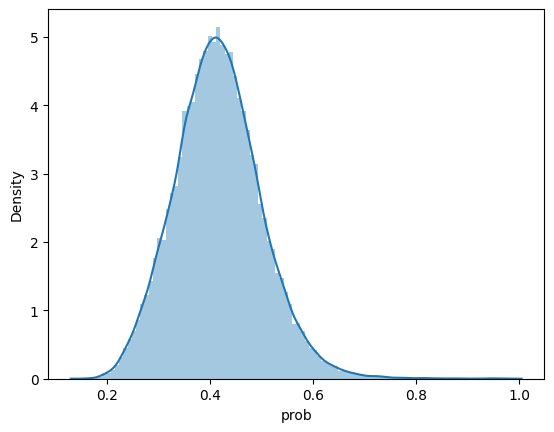

In [23]:
import seaborn as sns
sns.distplot(df['prob'], bins = 100)

In [24]:
import pandas as pd
import numpy as np

# ---------- 原有函数保持不变 ----------
def function_ls(prob_series, target_min, target_max, mode='L'):
    """
    将概率列通过二次函数单调拉伸到目标区间 [target_min, target_max]
    
    参数:
        prob_series: pandas.Series 或 numpy.ndarray，值在 [0,1] 之间
        target_min: 映射后的最小值（对应原始概率 0 或 1，取决于 mode）
        target_max: 映射后的最大值（对应原始概率 1 或 0，取决于 mode）
        mode: 'L' 表示概率越低分数越低（正向），'H' 表示概率越低分数越高（反向）
    
    返回:
        映射后的分数列，类型与输入相同
    """
    if isinstance(prob_series, pd.Series):
        probs = prob_series.values
        index = prob_series.index
        is_series = True
    else:
        probs = np.asarray(prob_series)
        is_series = False

    if mode == 'H':
        probs = 1 - probs

    c = target_min
    delta = target_max - target_min
    mean_prob = np.mean(probs)
    mid = (target_min + target_max) / 2.0

    if mean_prob == 0 or mean_prob == 1:
        a = 0.0
        b = delta
    else:
        numerator = mid - c - delta * mean_prob
        denominator = mean_prob**2 - mean_prob
        if denominator == 0:
            a = 0.0
        else:
            a = numerator / denominator
        b = delta - a

    if b < 0 or (2*a + b) < 0:
        a = 0.0
        b = delta

    a = round(a, 4)
    b = round(b, 4)
    c = round(c, 4)

    print(f"拉伸函数系数：a={a}, b={b}, c={c}")
    mapped = a * (probs ** 2) + b * probs + c
    mapped = np.round(mapped).astype(int)

    if is_series:
        return pd.Series(mapped, index=index)
    else:
        return mapped

def train_ls_coeff(prob_series, target_min, target_max, mode='L'):
    """
    基于整个训练集概率序列计算固定系数 a, b, c，不进行映射。
    返回字典 {'a': a, 'b': b, 'c': c, 'target_min': target_min, 'target_max': target_max, 'mode': mode}
    """
    probs = prob_series.values if isinstance(prob_series, pd.Series) else np.asarray(prob_series)
    if mode == 'H':
        probs = 1 - probs

    c = target_min
    delta = target_max - target_min
    mean_prob = np.mean(probs)
    mid = (target_min + target_max) / 2.0

    if mean_prob == 0 or mean_prob == 1:
        a = 0.0
        b = delta
    else:
        numerator = mid - c - delta * mean_prob
        denominator = mean_prob**2 - mean_prob
        if denominator == 0:
            a = 0.0
        else:
            a = numerator / denominator
        b = delta - a

    if b < 0 or (2*a + b) < 0:
        a = 0.0
        b = delta
        
    a = round(a, 4)
    b = round(b, 4)
    c = round(c, 4)

    return {'a': a, 'b': b, 'c': c, 'target_min': target_min, 'target_max': target_max, 'mode': mode}

def apply_ls_score(prob, coeff_dict):
    """
    使用训练好的系数字典，对单个概率或概率数组进行映射。
    prob: 数值或数组
    coeff_dict: 由 train_ls_coeff 返回的字典
    """
    a = coeff_dict['a']
    b = coeff_dict['b']
    c = coeff_dict['c']
    mode = coeff_dict['mode']
    is_scalar = np.isscalar(prob)
    x = np.asarray([prob]) if is_scalar else np.asarray(prob)
    if mode == 'H':
        x = 1 - x
    scores = a * (x ** 2) + b * x + c
    scores = np.round(scores).astype(int)
    return float(scores[0]) if is_scalar else scores

拉伸函数系数：a=171.6979, b=328.3021, c=500


<Axes: xlabel='score1', ylabel='Density'>

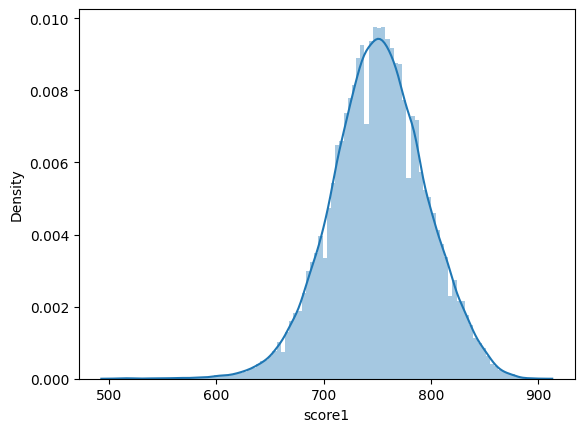

In [25]:
df['score1'] = function_ls(df['prob'], target_min=500, target_max=1000, mode='H')
sns.distplot(df['score1'], bins = 100)

拉伸函数系数：a=-233.5093, b=913.5093, c=320


<Axes: xlabel='score2', ylabel='Density'>

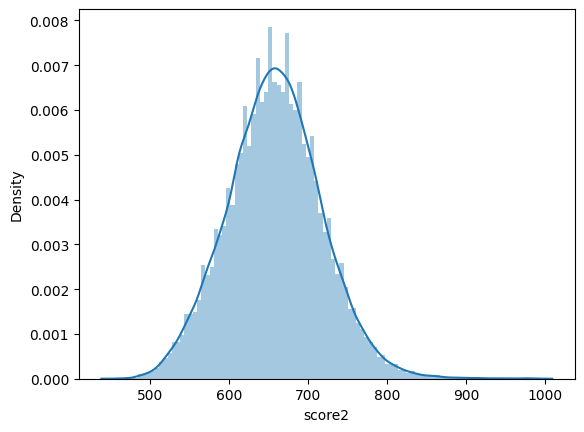

In [28]:
df['score2'] = function_ls(df['prob'], target_min=320, target_max=1000, mode='L')
sns.distplot(df['score2'], bins = 100)

# score_test

In [31]:
import pandas as pd
import numpy as np
import json

coeff_L = train_ls_coeff(df['prob'], target_min=550, target_max=1000, mode='L')
coeff_H = train_ls_coeff(df['prob'], target_min=550, target_max=1000, mode='H')

print("L 模式系数:", coeff_L)
print("H 模式系数:", coeff_H)


indices = [1, 10]  

test_cases = []


for idx in indices:
    prob_val = df['prob'].iloc[idx]
    score_L = apply_ls_score(prob_val, coeff_L)
    test_cases.append({
        "input": {"prob": float(prob_val)},
        "output": {"score": int(score_L)},
        "metadata": {"target_min": 300, "target_max": 1000, "mode": "L"}
    })


for idx in indices:
    prob_val = df['prob'].iloc[idx]
    score_H = apply_ls_score(prob_val, coeff_H)
    test_cases.append({
        "input": {"prob": float(prob_val)},
        "output": {"score": int(score_H)},
        "metadata": {"target_min": 300, "target_max": 1000, "mode": "H"}
    })


print(json.dumps(test_cases, indent=2))
with open('/opt/workspace/work/wangluyang/21.大模型探索/功能优化_io_source_json/score_test.json', 'w') as f:
    json.dump(test_cases, f, indent=2)

L 模式系数: {'a': -154.5282, 'b': 604.5282, 'c': 550, 'target_min': 550, 'target_max': 1000, 'mode': 'L'}
H 模式系数: {'a': 154.5281, 'b': 295.4719, 'c': 550, 'target_min': 550, 'target_max': 1000, 'mode': 'H'}
[
  {
    "input": {
      "prob": 0.413896769285202
    },
    "output": {
      "score": 774
    },
    "metadata": {
      "target_min": 300,
      "target_max": 1000,
      "mode": "L"
    }
  },
  {
    "input": {
      "prob": 0.5116914510726929
    },
    "output": {
      "score": 819
    },
    "metadata": {
      "target_min": 300,
      "target_max": 1000,
      "mode": "L"
    }
  },
  {
    "input": {
      "prob": 0.413896769285202
    },
    "output": {
      "score": 776
    },
    "metadata": {
      "target_min": 300,
      "target_max": 1000,
      "mode": "H"
    }
  },
  {
    "input": {
      "prob": 0.5116914510726929
    },
    "output": {
      "score": 731
    },
    "metadata": {
      "target_min": 300,
      "target_max": 1000,
      "mode": "H"
    }
  }
]
